In [1]:
pip install pandas numpy matplotlib seaborn mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [5]:
# Connect Python to MySQL database
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="surya",
    database="ecommerce_analytics"
)

In [6]:
print(conn)

### Load Tables into Pandas

In [7]:
customers = pd.read_sql("SELECT * FROM customers", conn)
orders = pd.read_sql("SELECT * FROM orders", conn)
order_items = pd.read_sql("SELECT * FROM order_items", conn)
products = pd.read_sql("SELECT * FROM products", conn)
payments = pd.read_sql("SELECT * FROM payments", conn)
reviews = pd.read_sql("SELECT * FROM reviews", conn)
sellers = pd.read_sql("SELECT * FROM sellers", conn)
category = pd.read_sql("SELECT * FROM category_translation", conn)

C:\Users\shash\AppData\Local\Temp\ipykernel_19152\557110238.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM customers", conn)
C:\Users\shash\AppData\Local\Temp\ipykernel_19152\557110238.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders", conn)
C:\Users\shash\AppData\Local\Temp\ipykernel_19152\557110238.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("SELECT * FROM order_items", conn)
C:\Users\shash\AppData\L

In [8]:
print(customers.shape)
print(orders.shape)
print(order_items.shape)
print(products.shape)
print(payments.shape)

(15963, 5)
(99441, 8)
(112650, 7)
(32340, 9)
(103886, 5)


### PHASE 2 — PYTHON EDA + VISUALIZATIONS

We’ll create charts that later go into Power BI / GitHub / resume screenshots.

In [ ]:
# Python EDA helps perform deeper analysis,
# data cleaning,
# visual storytelling,
# and dashboard-ready insights.

In [9]:
# Check missing values in all datasets
print(customers.isnull().sum())
print(orders.isnull().sum())
print(order_items.isnull().sum())
print(products.isnull().sum())
print(payments.isnull().sum())
print(reviews.isnull().sum())

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64
order_id                0
payment_sequential      0
pay

In [ ]:
# Missing value analysis helps identify incomplete records
# and necessary data cleaning steps.

#### Dataset Information

In [10]:
customers.info()
orders.info()
order_items.info()
products.info()
payments.info()
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               15963 non-null  object
 1   customer_unique_id        15963 non-null  object
 2   customer_zip_code_prefix  15963 non-null  object
 3   customer_city             15963 non-null  object
 4   customer_state            15963 non-null  object
dtypes: object(5)
memory usage: 623.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order

In [ ]:
# info() helps understand data types,
# memory usage,
# and null values.

### STEP 3 — Revenue Distribution Chart

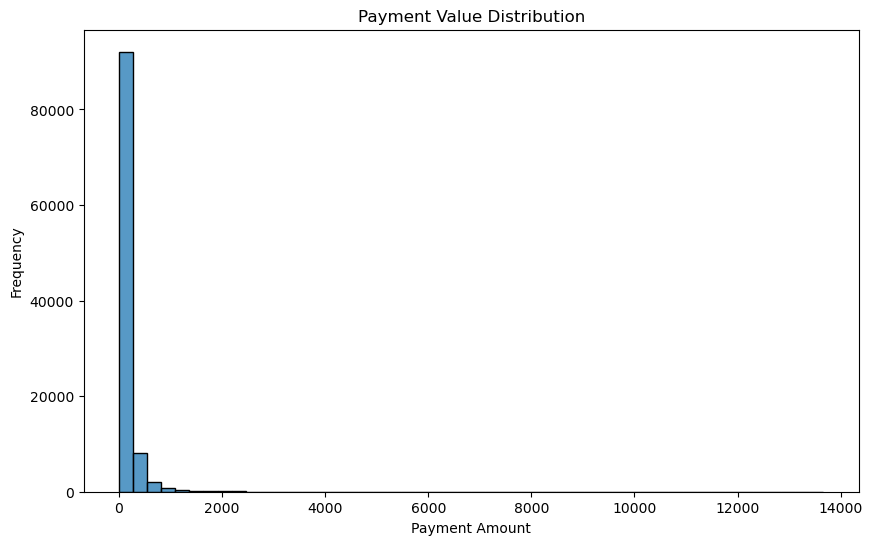

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(payments['payment_value'], bins=50)
plt.title("Payment Value Distribution")
plt.xlabel("Payment Amount")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Most transactions are small-value purchases
# with few high-value outliers.

### STEP 4 — Order Status Analysis

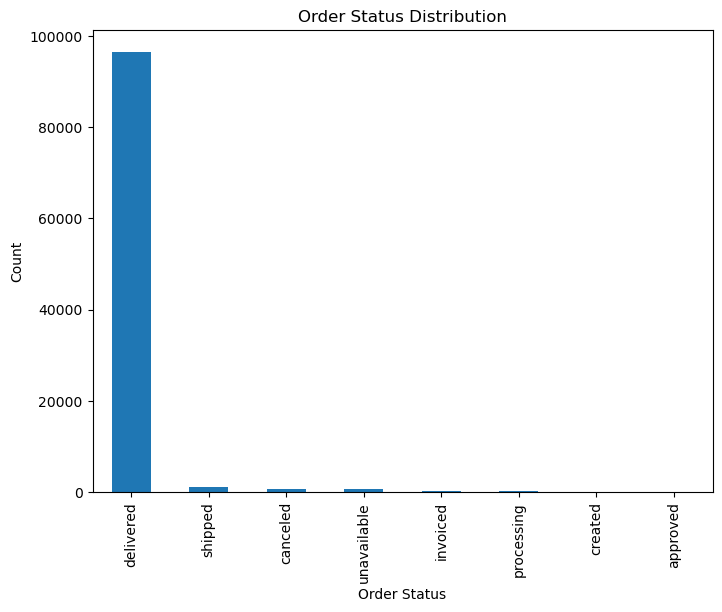

In [12]:
plt.figure(figsize=(8,6))
orders['order_status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

In [ ]:
### Insight

# Majority of orders are delivered,
# indicating strong fulfillment performance.

### STEP 5 — Payment Method Analysis

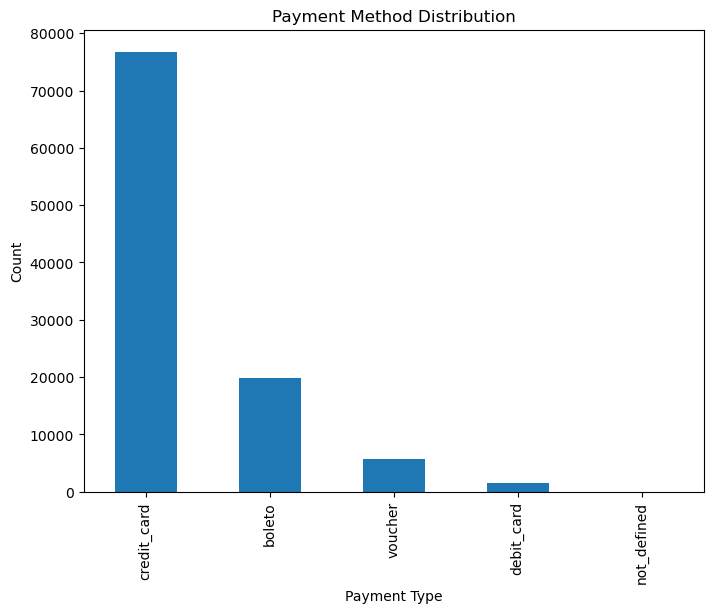

In [13]:
plt.figure(figsize=(8,6))
payments['payment_type'].value_counts().plot(kind='bar')
plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.show()

In [ ]:
# Credit card is likely dominant payment method.

### STEP 6 — Review Score Distribution

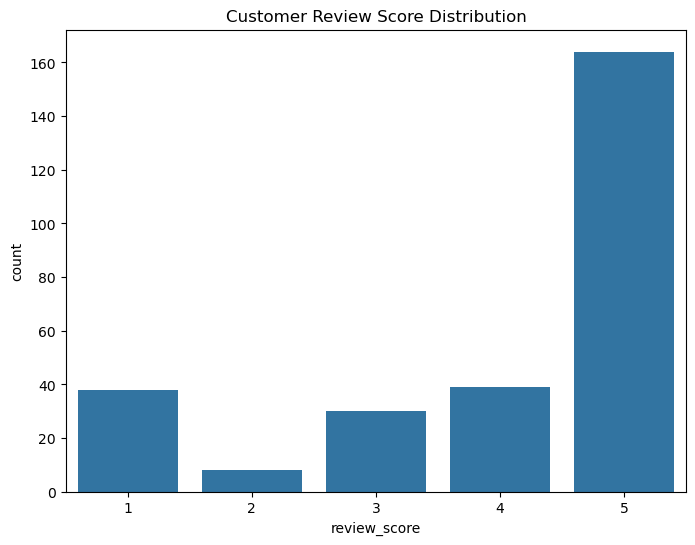

In [14]:
plt.figure(figsize=(8,6))
sns.countplot(x='review_score', data=reviews)
plt.title("Customer Review Score Distribution")
plt.show()

In [15]:
### Insight


# Customer ratings help assess satisfaction trends.

### STEP 7 — Top Customer States

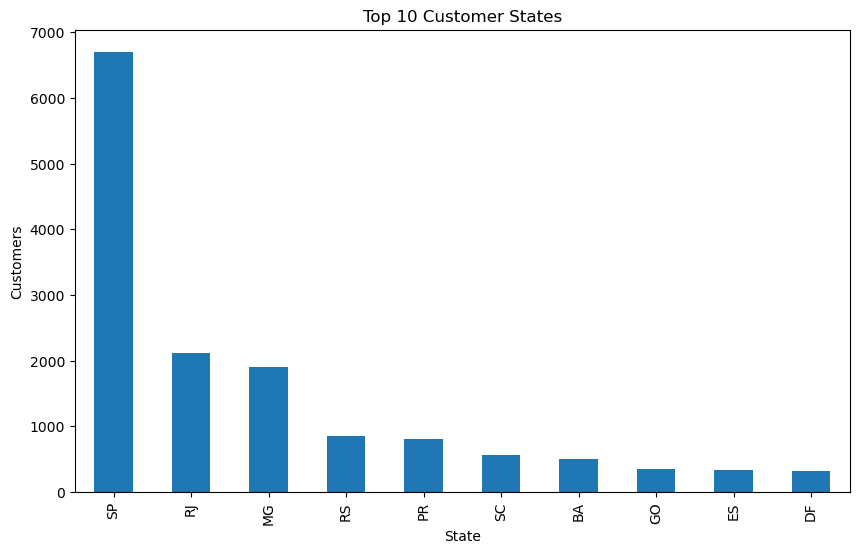

In [16]:
top_states = customers['customer_state'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar')
plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Customers")
plt.show()

### STEP 8 — Top Sellers

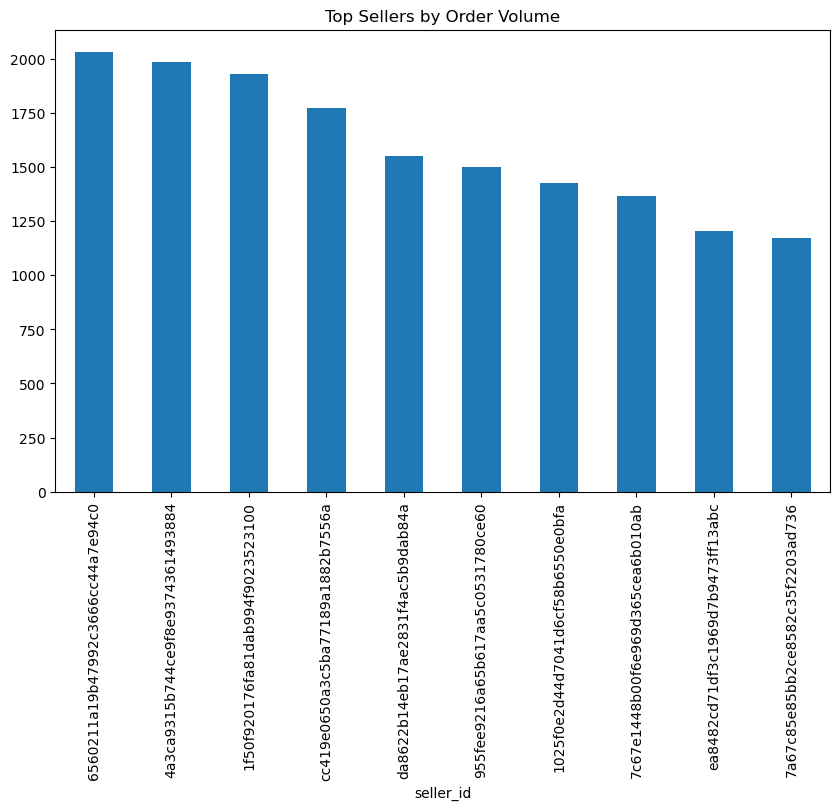

In [17]:
top_sellers = order_items['seller_id'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_sellers.plot(kind='bar')
plt.title("Top Sellers by Order Volume")
plt.show()

#### PHASE 3 — ADVANCED ANALYTICS

This is what increases shortlist value.

### PHASE 3 — ADVANCED ANALYTICS

This is what increases shortlist value.

In [18]:
# Merge customers with orders
customer_orders = customers.merge(
    orders,
    on='customer_id',
    how='inner'
)

# Merge payments
customer_orders_payments = customer_orders.merge(
    payments,
    on='order_id',
    how='inner'
)

# Merge order items
full_data = customer_orders_payments.merge(
    order_items,
    on='order_id',
    how='inner'
)

print(full_data.shape)
full_data.head()

(18901, 22)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1,credit_card,2,146.87,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1,credit_card,8,335.48,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1,credit_card,7,157.73,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1,credit_card,1,173.30,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1,credit_card,8,252.25,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25


In [ ]:
# Merging datasets creates a single analytical dataset
# for customer behavior and revenue analysis.

### STEP 2 — Convert Dates

In [19]:
full_data['order_purchase_timestamp'] = pd.to_datetime(
    full_data['order_purchase_timestamp']
)

### STEP 3 — Create RFM Analysis

In [20]:
snapshot_date = full_data['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = full_data.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98
0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76
000a5ad9c4601d2bbdd9ed765d5213b3,384,1,91.28
000bfa1d2f1a41876493be685390d6d3,334,1,46.85
000c8bdb58a29e7115cfc257230fb21b,260,1,29.00


In [ ]:
# Recency = how recently customer purchased
# Frequency = how often customer purchased
# Monetary = total customer spending

### STEP 4 — RFM Visualization

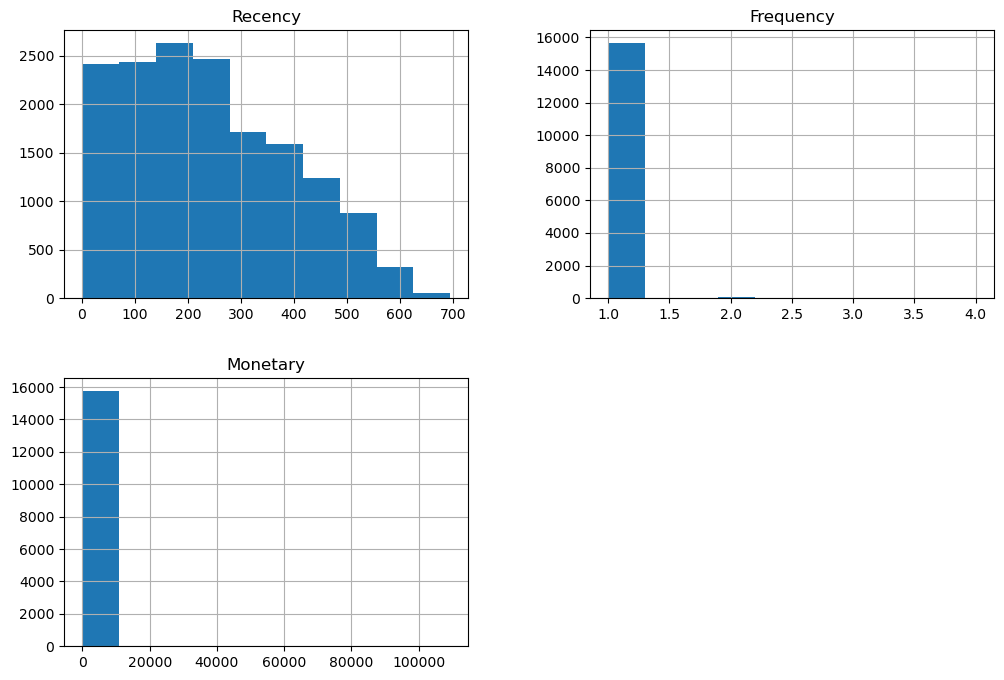

In [21]:
rfm.hist(figsize=(12,8))
plt.show()

### STEP 5 — Pareto Analysis

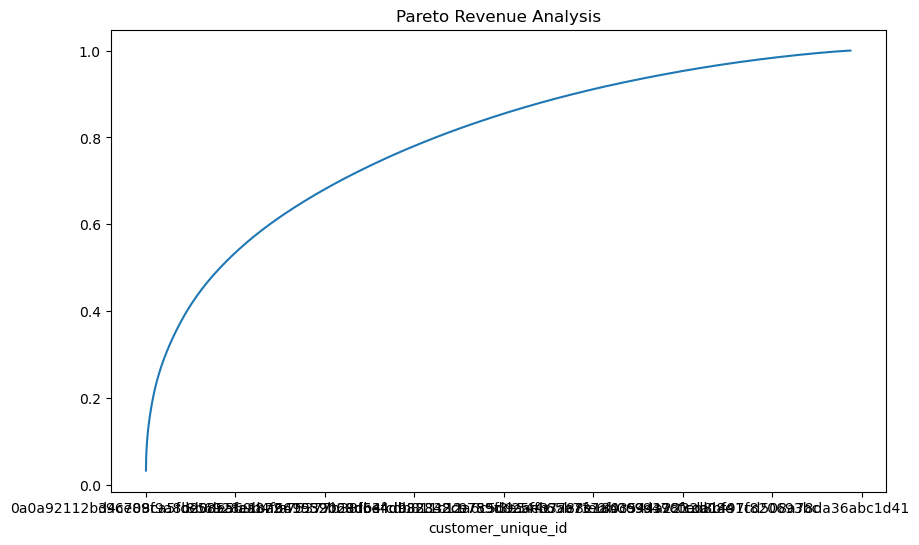

In [22]:
customer_revenue = rfm.sort_values(
    by='Monetary',
    ascending=False
)

customer_revenue['cumulative_revenue'] = (
    customer_revenue['Monetary'].cumsum() /
    customer_revenue['Monetary'].sum()
)

customer_revenue['cumulative_revenue'].plot(figsize=(10,6))
plt.title("Pareto Revenue Analysis")
plt.show()

In [ ]:
### Insight

# Small percentage of customers may contribute majority of revenue.

### STEP 6 — Monthly Revenue Trend

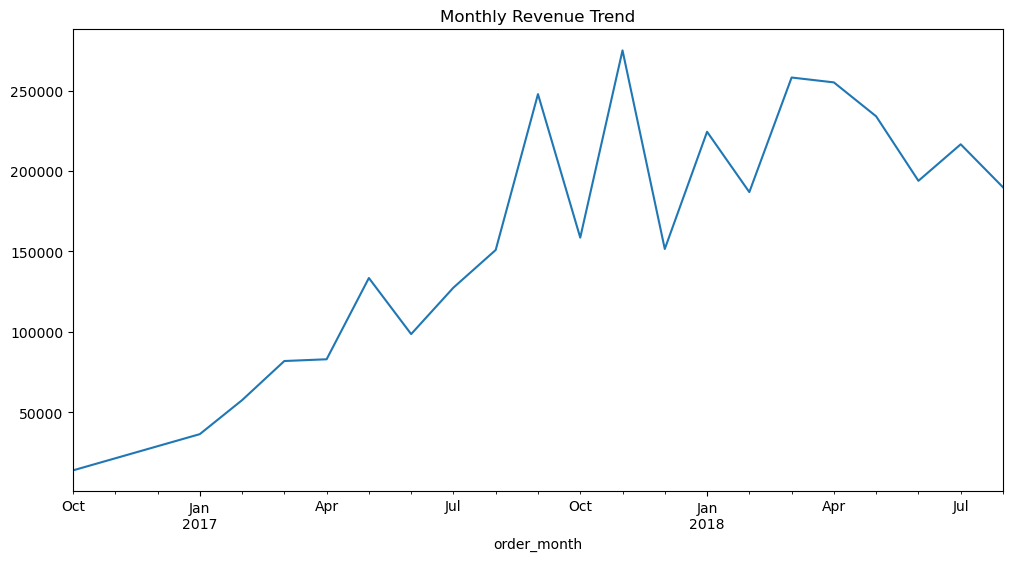

In [23]:
full_data['order_month'] = full_data['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = full_data.groupby('order_month')['payment_value'].sum()

monthly_revenue.plot(figsize=(12,6))
plt.title("Monthly Revenue Trend")
plt.show()

In [26]:
print(category.columns)

Index(['ï»¿product_category_name', 'product_category_name_english'], dtype='object')


In [27]:
# Fix encoding issue in category table column name
category.columns = [
    'product_category_name',
    'product_category_name_english'
]

In [28]:
print(category.columns)

Index(['product_category_name', 'product_category_name_english'], dtype='object')


In [25]:
print(products.columns)

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')


#### STEP 7 — Top Product Categories

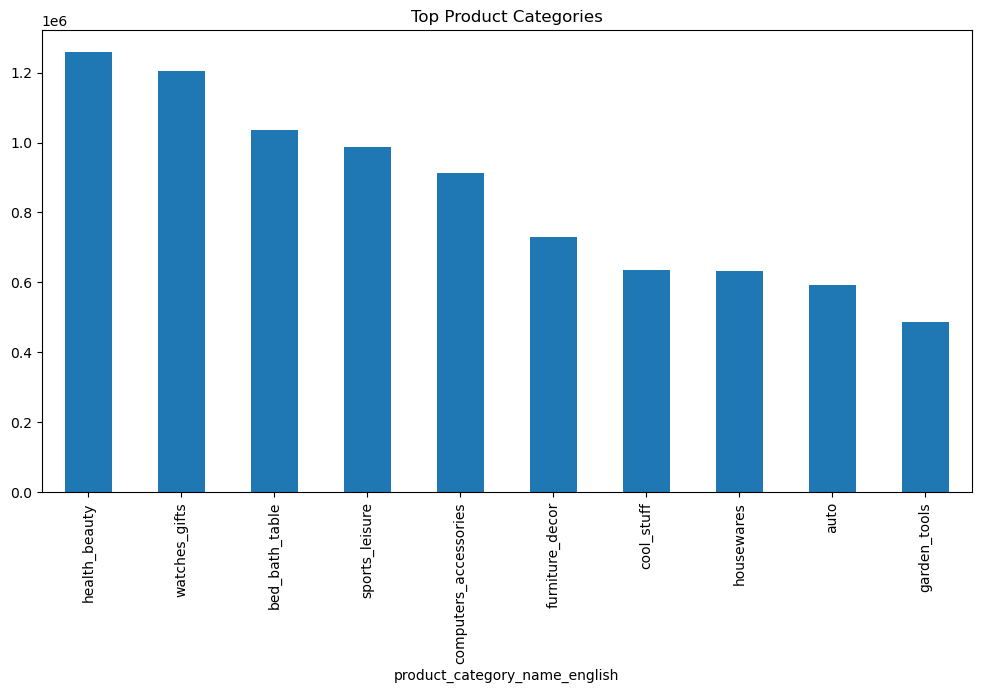

In [29]:
product_data = order_items.merge(
    products,
    on='product_id'
).merge(
    category,
    left_on='product_category_name',
    right_on='product_category_name'
)

top_categories = product_data.groupby(
    'product_category_name_english'
)['price'].sum().sort_values(ascending=False).head(10)

top_categories.plot(kind='bar', figsize=(12,6))
plt.title("Top Product Categories")
plt.show()

In [ ]:
# CSV encoding introduced incorrect column names
# Renamed columns for consistent joins

In [30]:
print(category.columns)

Index(['product_category_name', 'product_category_name_english'], dtype='object')


### STEP 1 — Cohort Analysis

This is very strong for Data Analyst resumes.

What is it?

Tracks whether customers return after their first purchase.

Write this note:

# Cohort analysis helps measure customer retention over time.

In [31]:
# Create invoice month
full_data['order_month'] = full_data['order_purchase_timestamp'].dt.to_period('M')

# First purchase month
full_data['cohort_month'] = full_data.groupby(
    'customer_unique_id'
)['order_month'].transform('min')

# Cohort index
full_data['cohort_index'] = (
    full_data['order_month'].astype(int)
    - full_data['cohort_month'].astype(int)
)

full_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_month,cohort_month,cohort_index
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,146.87,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,2017-05,2017-05,0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,335.48,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,2018-01,2018-01,0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,157.73,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,2018-05,2018-05,0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,173.30,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,2018-03,2018-03,0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,252.25,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,2018-07,2018-07,0


#### STEP 2 — Retention Table

In [32]:
cohort_data = full_data.groupby(
    ['cohort_month', 'cohort_index']
)['customer_unique_id'].nunique().reset_index()

cohort_counts = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

cohort_counts

cohort_index,0,1,2,3,4,5,6,7,9,10,11,12,15,20
cohort_month,,,,,,,,,,,,,,
2016-10,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2017-01,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02,282.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03,426.0,2.0,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
2017-04,383.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-05,590.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-06,510.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN
2017-07,654.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN
2017-08,723.0,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN


### STEP 3 — Retention Percentage

In [33]:
retention = cohort_counts.divide(
    cohort_counts.iloc[:, 0],
    axis=0
)

retention

cohort_index,0,1,2,3,4,5,6,7,9,10,11,12,15,20
cohort_month,,,,,,,,,,,,,,
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018182
2017-01,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03,1.0,0.004695,NaN,NaN,0.002347,NaN,0.002347,NaN,NaN,NaN,NaN,NaN,0.002347,NaN
2017-04,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-05,1.0,0.001695,0.001695,0.001695,0.001695,NaN,0.001695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,NaN,NaN,NaN,NaN,0.001961,NaN,NaN,0.001961,0.001961,0.001961,NaN,NaN,NaN
2017-07,1.0,NaN,0.001529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001529,0.001529,NaN,NaN
2017-08,1.0,NaN,NaN,0.001383,NaN,0.001383,NaN,NaN,NaN,0.001383,NaN,NaN,NaN,NaN


### STEP 4 — Retention Heatmap

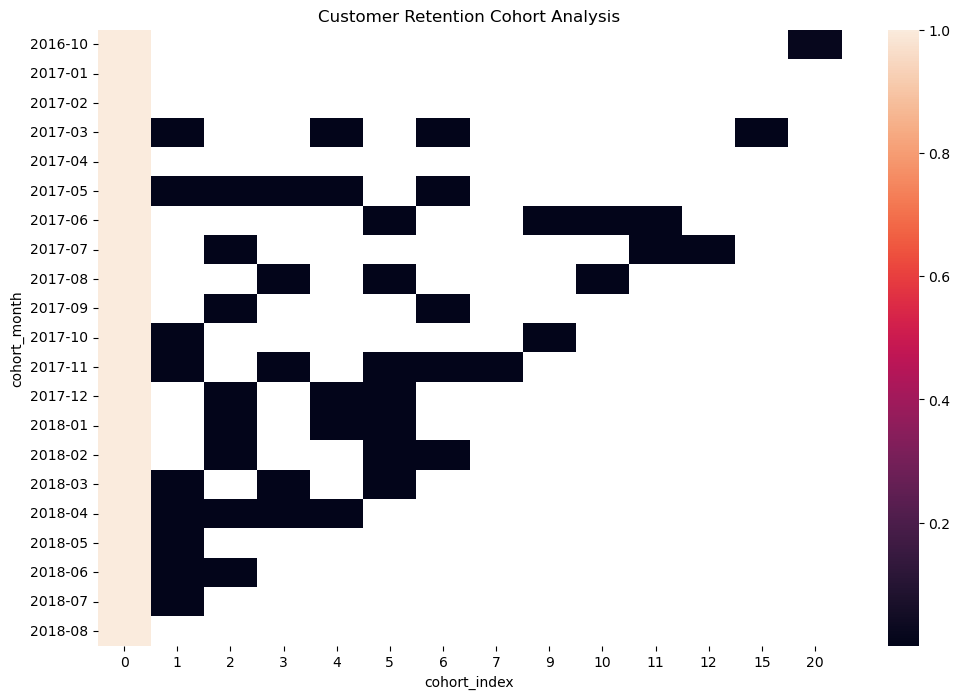

In [34]:
plt.figure(figsize=(12,8))
sns.heatmap(retention, annot=False)
plt.title("Customer Retention Cohort Analysis")
plt.show()

In [ ]:
# Cohort analysis helps identify customer retention patterns
# across acquisition periods.

#### STEP 5 — RFM Customer Segmentation

In [35]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

### STEP 6 — Final RFM Score

In [36]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
customer_unique_id,,,,,,,
0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,3,1,3,313
0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76,3,1,3,313
000a5ad9c4601d2bbdd9ed765d5213b3,384,1,91.28,1,1,2,112
000bfa1d2f1a41876493be685390d6d3,334,1,46.85,2,1,1,211
000c8bdb58a29e7115cfc257230fb21b,260,1,29.00,2,1,1,211


### STEP 7 — Segment Customers

In [37]:
def segment_customer(score):
    if score == '444':
        return 'Champions'
    elif score[0] == '4':
        return 'Loyal Customers'
    elif score[0] == '1':
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

rfm['Segment'].value_counts()

Segment
Regular            7847
At Risk            3932
Loyal Customers    3696
Champions           276
Name: count, dtype: int64

### STEP 8 — Visualize Segments

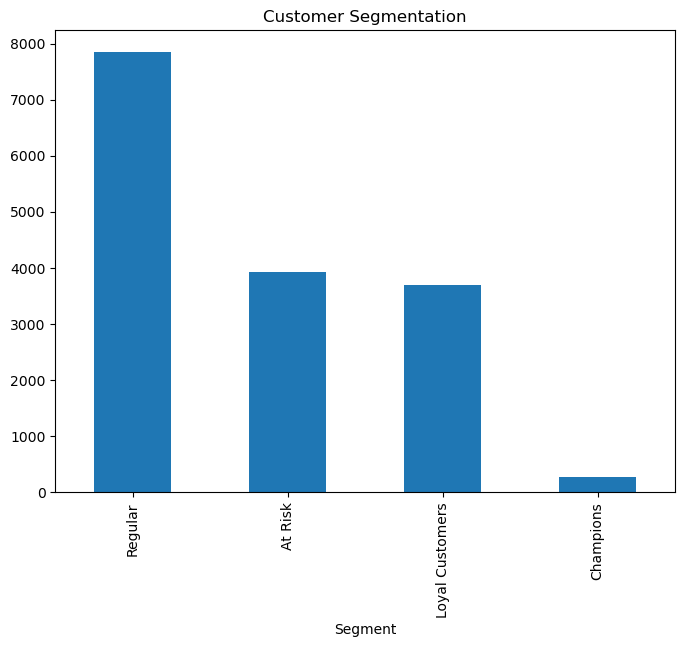

In [38]:
plt.figure(figsize=(8,6))
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segmentation")
plt.show()

### STEP 1 — Export Data from Python

In [39]:
full_data.to_csv("full_data.csv", index=False)
rfm.to_csv("rfm_segments.csv")
retention.to_csv("cohort_retention.csv")

In [ ]:
# Export cleaned analytical datasets for Power BI dashboard creation.